In [5]:
pip install torch torchvision


Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.9 MB 6.3 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 6.4 MB/s eta 0:00:01
     |████████████████████████████████| 5.3 MB 25.6 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [6]:
import torch
import torchvision
print(torch.__version__)
print(torchvision.__version__)
print(torch.backends.mps.is_available())

2.8.0
0.23.0
True


In [ ]:
import random
import numpy as np
import torch
from torchvision import datasets, transforms

# -----------------------------
# Set random seed (Reproducibility)
# -----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# If using Apple Silicon GPU (MPS)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

# -----------------------------
# Device
# -----------------------------
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Using device: {device}")

Using device: mps


In [7]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training images :", len(train_data))
print("Testing images  :", len(test_data))

Training images : 60000
Testing images  : 10000


In [10]:
pip install matplotlib


Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 7.8 MB 9.5 MB/s eta 0:00:01
     |████████████████████████████████| 2.9 MB 40.6 MB/s eta 0:00:01
     |████████████████████████████████| 122 kB 29.9 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 7.6 MB/s  eta 0:00:01
     |████████████████████████████████| 249 kB 29.9 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


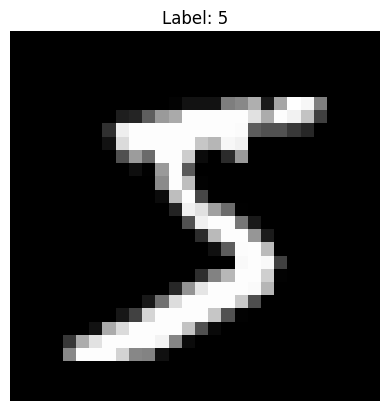

In [13]:
import matplotlib.pyplot as plt

image, label = train_data[0]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

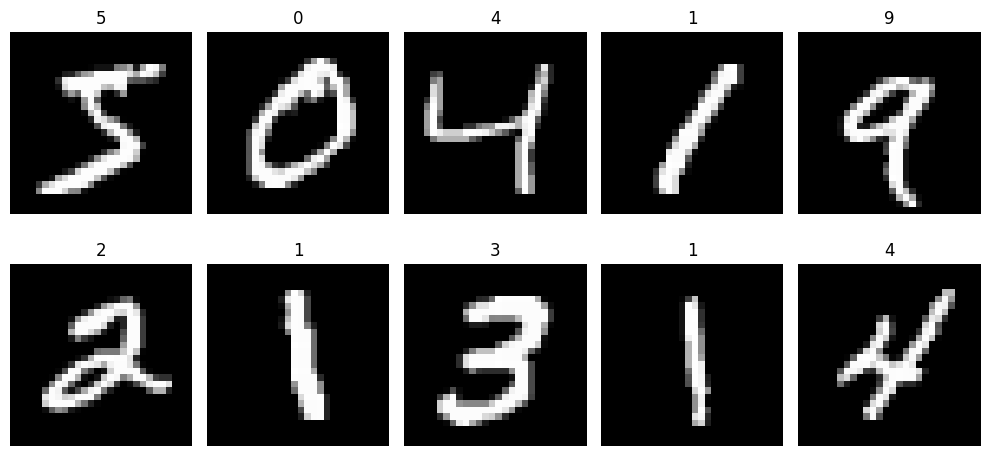

In [14]:
fig, axes = plt.subplots(2,5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    image, label = train_data[i]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(len(train_loader))

938


In [17]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [18]:
import torch.nn as nn

class MLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.flatten = nn.Flatten()

        self.network = nn.Sequential(

            nn.Linear(28 * 28, 128),

            nn.ReLU(),

            nn.Linear(128, 64),

            nn.ReLU(),

            nn.Linear(64, 10)

        )

    def forward(self, x):

        x = self.flatten(x)

        return self.network(x)

In [19]:
model = MLP().to(device)

print(model)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [20]:
sample_images, sample_labels = next(iter(train_loader))

sample_images = sample_images.to(device)

outputs = model(sample_images)

print(outputs.shape)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

torch.Size([64, 10])


In [21]:
model.train()

running_loss = 0

for images, labels in train_loader:

    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

print("Average Loss:", running_loss / len(train_loader))

Average Loss: 0.3358762754496735
